### Reachable set-based global optimizer (Semi-Infinite Programming) 
Ref: Koenig and D'Amico "Fast Algorithm for Fuel-Optimal Impulsive Control of Linear Systems with Time-Varying Cost"


In [2]:
%load_ext autoreload
%autoreload 2

import os 
import sys 
import numpy as np 
import matplotlib.pyplot as plt

def find_root_path(path:str, word:str):
    parts = path.split(word, 1)
    if len(parts) > 1:
        return parts[0] + word
    else:
        return path

root_folder = find_root_path(os.getcwd(), 'scp_elliptic_orbits')
sys.path.append(root_folder)

from util_dyn import * 
from impulsiveSIP import *
# from src.scenarios.rpod.parameters import * 



In [5]:

B = lambda t: cim_eroe(propagate_oe(oec0, t-t0_sec, mu_E, J2), mu_E)
Φ = lambda t2, t1: stm_eroe(propagate_oe(oec0, t1-t0_sec, mu_E, J2), t2-t1, mu_E, R_E, J2)
Γ = lambda t: stm_eroe(propagate_oe(oec0, t-t0_sec, mu_E, J2), tf_sec-t, mu_E, R_E, J2) @ B(t)  

SIP = impulsiveSIP(Φ, Γ, roe0, roef, t0_sec, tf_sec)
topt, uopt, λopt = SIP.solve()
gU = SIP._compute_gU(np.linspace(t0_sec, tf_sec, 1000), λopt)
# only take a control magnitude larger than epsilon
epsilon = 1e-3
topt, uopt = topt[np.linalg.norm(uopt, axis=1) > epsilon], uopt[np.linalg.norm(uopt, axis=1) > epsilon] 
uopt = uopt.T

print("solved!")
print("optimal burn time: ", topt)
print("optimal control: ", uopt)    
print("optimal cost: ", np.sum(np.linalg.norm(uopt, axis=0)))

<function <lambda> at 0x12cbcbac0>


NameError: name 'roe0' is not defined

Text(0.5, 1.0, 'Koenig Impulsive SIP Control History')

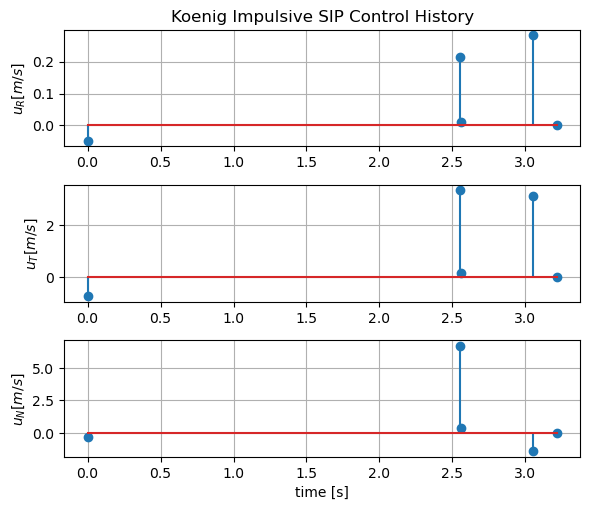

In [93]:
topt_ = np.hstack((topt, tf_sec))
uopt_ = np.concatenate((uopt, np.zeros((3, 1))), axis=1)  # add zero control at the end
fig = plt.figure(figsize=(6, 5))
ax1 = fig.add_subplot(311)
ax1.stem(topt_/period, uopt_[0,:], label='$u_R$')
ax1.grid()
ax1.set_ylabel('$u_R [m/s]$')
ax2 = fig.add_subplot(312)
ax2.stem(topt_/period, uopt_[1,:], label='$u_T$')
ax2.grid()
ax2.set_ylabel('$u_T [m/s]$')
ax3 = fig.add_subplot(313)
ax3.stem(topt_/period, uopt_[2,:], label='$u_N$')
ax3.grid()
ax3.set_ylabel('$u_N [m/s]$')
ax3.set_xlabel('time [s]')
plt.tight_layout()
ax1.set_title('Koenig Impulsive SIP Control History')


In [ ]:
aroe_hist = np.zeros((6, 2*len(topt)+1))
aroe_hist[:,0] = roe0

t_prev = 0.0
oe_k = oec0.copy()

eta   = np.sqrt(1 - oec0[1]**2)
kappa = 3/4 * J2*R_E**2*np.sqrt(mu_E) / (oec0[0]**(7/2)*eta**4)
P = 3*np.cos(oec0[2])**2 - 1
Q = 5*np.cos(oec0[2])**2 - 1
RAAN_dot = -2*np.cos(oec0[2])*kappa
aop_dot = kappa * Q
M_dot = n + kappa*eta*P

for idx, t_burn in enumerate(topt):
    dt = t_burn - t_prev
    
    col_prev = 2*idx
    col_prop = col_prev + 1
    col_imp = col_prev + 2

    aroe_hist[:,col_prop] = Φ(t_burn, t_prev) @ aroe_hist[:,col_prev]
    oe_k[3] += RAAN_dot * dt 
    oe_k[4] += aop_dot * dt 
    oe_k[5] += M_dot * dt
    aroe_hist[:,col_imp] = aroe_hist[:,col_prop] + B(t_burn) @ uopt[:,idx]
    t_prev = t_burn

tvec = np.concatenate(([0.0], np.repeat(topt, 2)))

In [76]:
oec_hist = propagate_oe(oec0, tvec, mu_E, J2)
dx = eroe_to_rtn(aroe_hist, oec_hist)
tvec

array([    0.        ,     0.        ,     0.        , 28612.61261261,
       28612.61261261, 28648.64864865, 28648.64864865, 34162.16216216,
       34162.16216216])

In [77]:
print(np.shape(dx), np.shape(uopt), np.shape(tvec)) 

(6, 9) (3, 4) (9,)


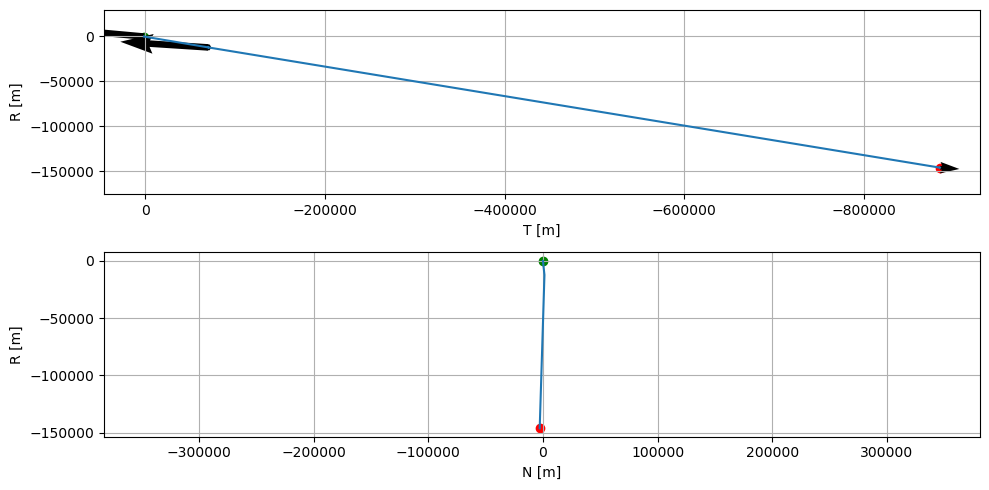

In [78]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(211)
ax1.scatter(dx[1,0], dx[0,0], color='r')
ax1.scatter(dx[1,-1], dx[0,-1], color='g')
ax1.plot(dx[1,:], dx[0,:])
ax1.quiver(dx[1,1::2], dx[0,1::2], -uopt[1,:], uopt[0,:])
ax1.set_xlabel('T [m]')
ax1.set_ylabel('R [m]')
ax1.grid()
ax1.invert_xaxis()
ax1.axis('equal')
ax2 = fig.add_subplot(212)  
ax2.scatter(dx[2,0], dx[0,0], color='r')
ax2.scatter(dx[2,-1], dx[0,-1], color='g')
ax2.plot(dx[2,:], dx[0,:])
ax2.set_xlabel('N [m]')
ax2.set_ylabel('R [m]')
ax2.grid()
ax2.axis('equal')
fig.tight_layout()


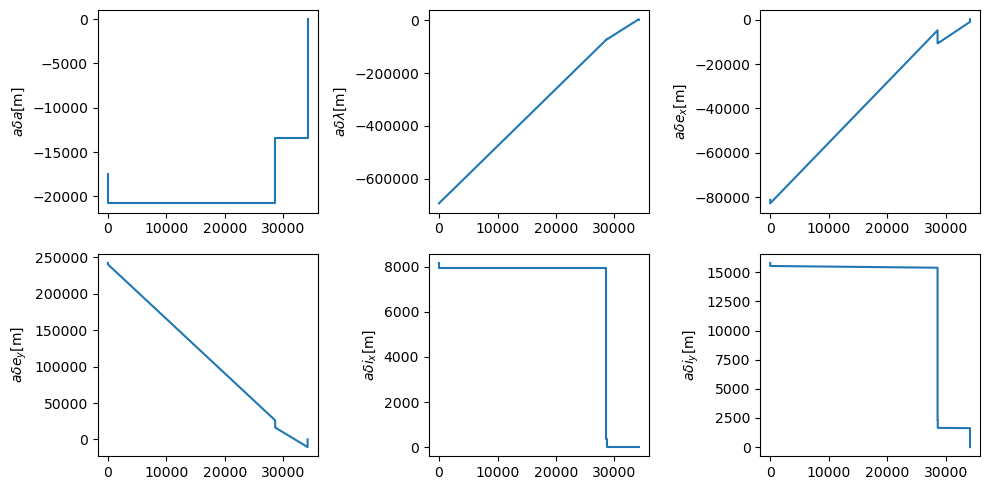

In [79]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(231)
ax1.plot(tvec, aroe_hist[0,:])
ax1.set_ylabel('$a\delta a$[m]')
ax2 = fig.add_subplot(232)
ax2.plot(tvec, aroe_hist[1,:])
ax2.set_ylabel('$a\delta \lambda$[m]')
ax3 = fig.add_subplot(233)
ax3.plot(tvec, aroe_hist[2,:])
ax3.set_ylabel('$a\delta e_x$[m]')
ax4 = fig.add_subplot(234)
ax4.plot(tvec, aroe_hist[3,:])
ax4.set_ylabel('$a\delta e_y$[m]')
ax5 = fig.add_subplot(235)
ax5.plot(tvec, aroe_hist[4,:])
ax5.set_ylabel('$a\delta i_x$[m]')
ax6 = fig.add_subplot(236)
ax6.plot(tvec, aroe_hist[5,:])
ax6.set_ylabel('$a\delta i_y$[m]')
fig.tight_layout()



Text(0, 0.5, 'gU')

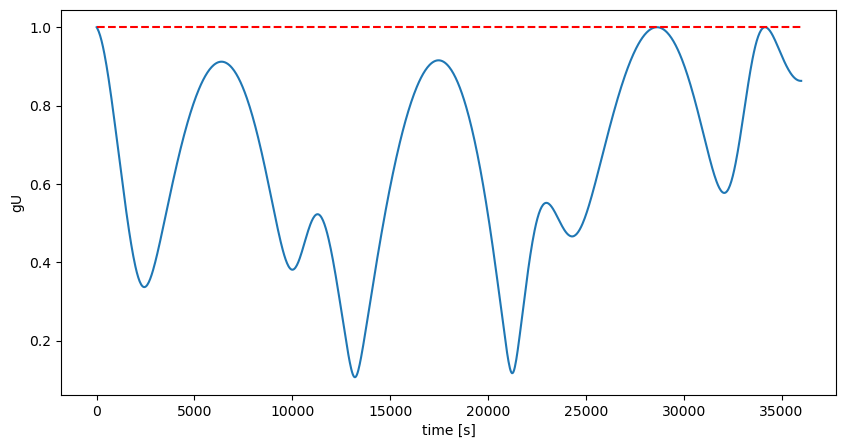

In [80]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111) 
ax.plot(np.linspace(t0_sec, tf_sec, 1000), gU)
ax.hlines(1, t0_sec, tf_sec, color='r', linestyle='--')
ax.set_xlabel('time [s]')
ax.set_ylabel('gU')

### comparision with CVXPY (CVX solution)

In [81]:
from src.scenarios.rpod.optimization import NonConvexOCP, solve_scp_ocp 
from src.scenarios.rpod.model import DynamicsModel


In [82]:

obs0 = {
        'time' : 0.0,
        'state' : roe0,
        'goal' : roef,
        'dv' : np.zeros(1),
        'ttg' : tf_sec,
        'dt' : dt_sec,
        'observation' : None,
        'oe': oec0.reshape(-1, 1),
    }

problem = NonConvexOCP(
    dyn_model=DynamicsModel,
    prob_definition={
        't_i' : 0,
        't_f' : n_time,
        'tvec_sec' : tvec_sec,
        'chance' : True,
        'current_obs' : obs0,
        'local_state_goal' : None,
        'hardness' : False,
        'convexified_problem' : True,
        'verbose' : False,
        'Ds' : Ds, 
        'Da' : Da,
        'verbose' : True,
        'state_def' : state
    }, 
)

In [83]:
sol, log = solve_scp_ocp(prob=problem)
roe_opt = sol["states"]
ucvx = sol["actions"]
rtn_opt = problem.f_2rtn(roe_opt, oec)
cost = np.sum(np.linalg.norm(ucvx, axis=0)) 
print(f"Final cost: {cost:.3f} m/s")
print('rtnf =', rtn_opt[:,-1])


Final cost: 12.142 m/s
rtnf = [ 1.42987248e-09  1.81610494e+03  3.91251200e-10 -4.39858130e-11
  3.36168130e-01 -2.81023703e-11]


Text(0.5, 1.0, 'CVXPY Control History')

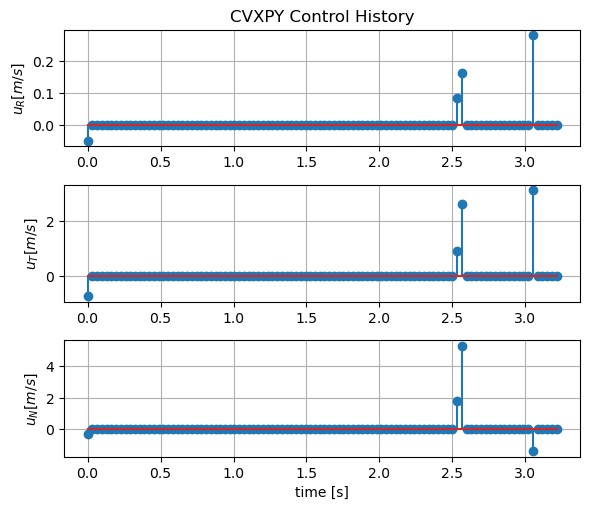

In [87]:
fig = plt.figure(figsize=(6, 5))
ax1 = fig.add_subplot(311)
ax1.stem(tvec_sec/period, ucvx[0,:], label='$u_R$')
ax1.grid()
ax1.set_ylabel('$u_R [m/s]$')
ax2 = fig.add_subplot(312)
ax2.stem(tvec_sec/period, ucvx[1,:], label='$u_T$')
ax2.grid()
ax2.set_ylabel('$u_T [m/s]$')
ax3 = fig.add_subplot(313)
ax3.stem(tvec_sec/period, ucvx[2,:], label='$u_N$')
ax3.grid()
ax3.set_ylabel('$u_N [m/s]$')
ax3.set_xlabel('time [s]')
plt.tight_layout()
ax1.set_title('CVXPY Control History')